In [2]:
# Tratamento de Dados - Wind Turbines
#*Análise e tratamento POR TURBINA com detecção DBSCAN de outliers (sem alteração) e preenchimento de valores vazios**

#importante**: Cada turbina é processada SEPARADAMENTE para evitar contaminação entre turbinas defeituosas e saudáveis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

In [4]:
# Carregar bases de dados (delimitador = ponto-e-vírgula)
df_turbine = pd.read_csv('Wind-Turbine-SCADA-signals-2017_0.csv', sep=';')
df_metmast = pd.read_csv('Onsite-MetMast-SCADA-data-2017 (3).csv', sep=';')

# Limpar espaços nos nomes das colunas
df_turbine.columns = df_turbine.columns.str.strip()
df_metmast.columns = df_metmast.columns.str.strip()

print(f"Wind Turbine SCADA: {df_turbine.shape} | Valores vazios: {df_turbine.isnull().sum().sum()}")
print(f"Turbinas únicas: {df_turbine['Turbine_ID'].unique() if 'Turbine_ID' in df_turbine.columns else 'Coluna não encontrada'}")

print(f"\nOnsite MetMast: {df_metmast.shape} | Valores vazios: {df_metmast.isnull().sum().sum()}")

Wind Turbine SCADA: (209236, 83) | Valores vazios: 8
Turbinas únicas: ['T06' 'T01' 'T07' 'T11']

Onsite MetMast: (34831, 41) | Valores vazios: 18


In [5]:
# Função de detecção de outliers com PCA + DBSCAN (otimizada)
def detectar_outliers_dbscan(df, eps=2.0, min_samples=5, n_components=0.95):
    """
    Detecta outliers usando PCA + DBSCAN
    - Reduz dimensionalidade com PCA (80D → ~10-15D)
    - Aplica DBSCAN no espaço reduzido
    - n_components: variância a reter (0.95 = 95%)
    - eps: raio de vizinhança (ajustado para espaço PCA)
    """
    df_resultado = df.copy()
    
    # Selecionar apenas colunas numéricas
    colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remover colunas com todos NaN
    colunas_validas = [col for col in colunas_numericas if df[col].notna().sum() > 0]
    
    if len(colunas_validas) == 0:
        df_resultado['outlier_flag'] = False
        return df_resultado
    
    # Preparar dados para DBSCAN
    dados_para_cluster = df[colunas_validas].copy()
    
    # Preencher NaN temporariamente apenas para clustering
    imputer_temp = KNNImputer(n_neighbors=3)
    dados_preenchidos = pd.DataFrame(
        imputer_temp.fit_transform(dados_para_cluster),
        columns=colunas_validas,
        index=dados_para_cluster.index
    )
    
    # Normalizar ANTES do PCA
    scaler = StandardScaler()
    dados_normalizados = scaler.fit_transform(dados_preenchidos)
    
    # Aplicar PCA: redução de dimensionalidade
    pca = PCA(n_components=n_components)
    dados_pca = pca.fit_transform(dados_normalizados)
    
    n_componentes = dados_pca.shape[1]
    variancia_explicada = pca.explained_variance_ratio_.sum() * 100
    
    print(f"   PCA: {len(colunas_validas)}D → {n_componentes}D ({variancia_explicada:.1f}% variância)")
    
    # Aplicar DBSCAN no espaço reduzido
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    clusters = dbscan.fit_predict(dados_pca)
    
    # Marcar outliers (label -1)
    df_resultado['outlier_flag'] = (clusters == -1)
    
    return df_resultado

In [6]:
# Função de preenchimento de valores vazios (método simples e conservador)
def preencher_valores_vazios(df, metodo='knn', n_neighbors=3):
    """
    Preenche valores vazios com método de baixo impacto
    metodo: 'knn' (padrão) ou 'ffill' (forward fill)
    """
    df_preenchido = df.copy()
    colunas_numericas = df_preenchido.select_dtypes(include=[np.number]).columns.tolist()
    
    # Remover coluna de flag se existir
    if 'outlier_flag' in colunas_numericas:
        colunas_numericas.remove('outlier_flag')
    
    if metodo == 'knn':
        # KNN Imputer: usa vizinhos próximos (baixo impacto)
        imputer = KNNImputer(n_neighbors=n_neighbors)
        df_preenchido[colunas_numericas] = imputer.fit_transform(df_preenchido[colunas_numericas])
    
    elif metodo == 'ffill':
        # Forward Fill: propaga último valor válido
        df_preenchido[colunas_numericas] = df_preenchido[colunas_numericas].fillna(method='ffill')
        # Preencher valores iniciais com backward fill se necessário
        df_preenchido[colunas_numericas] = df_preenchido[colunas_numericas].fillna(method='bfill')
    
    return df_preenchido

## Processamento Base 1: Wind Turbine SCADA
**Separando e processando cada turbina individualmente**

In [7]:
# Diagnóstico: Visualizar dimensionalidade por turbina
print("=" * 70)
print("ANÁLISE DE DIMENSIONALIDADE POR TURBINA")
print("=" * 70)

for turbine_id in df_turbine['Turbine_ID'].unique():
    df_turb = df_turbine[df_turbine['Turbine_ID'] == turbine_id]
    
    # Colunas numéricas
    colunas_num = df_turb.select_dtypes(include=[np.number]).columns.tolist()
    
    # Colunas com TODOS os valores NaN
    colunas_totalmente_vazias = [col for col in colunas_num if df_turb[col].notna().sum() == 0]
    
    # Colunas com ALGUNS valores NaN
    colunas_parcialmente_vazias = [col for col in colunas_num 
                                   if 0 < df_turb[col].isna().sum() < len(df_turb)]
    
    print(f"\n{turbine_id}:")
    print(f"  Total colunas numéricas: {len(colunas_num)}")
    print(f"  Colunas 100% vazias: {len(colunas_totalmente_vazias)}")
    print(f"  Colunas parcialmente vazias: {len(colunas_parcialmente_vazias)}")
    print(f"  ✅ Colunas válidas para PCA: {len(colunas_num) - len(colunas_totalmente_vazias)}")
    
    if colunas_totalmente_vazias:
        if len(colunas_totalmente_vazias) <= 5:
            print(f"  ⚠️ Colunas removidas: {colunas_totalmente_vazias}")
        else:
            print(f"  ⚠️ Colunas removidas ({len(colunas_totalmente_vazias)}): {colunas_totalmente_vazias[:5]}...")

print("\n" + "=" * 70)
print("💡 É normal e esperado que turbinas tenham diferentes números de")
print("   dimensões devido a sensores específicos desligados ou com falha.")
print("=" * 70)

ANÁLISE DE DIMENSIONALIDADE POR TURBINA

T06:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T06:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T01:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T01:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T07:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T07:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

T11:
  Total colunas numéricas: 81
  Colunas 100% vazias: 0
  Colunas parcialmente vazias: 2
  ✅ Colunas válidas para PCA: 81

💡 É normal e esperado que turbinas tenham diferentes números de
   dim

In [8]:
# Otimizar parâmetros DBSCAN com PCA
from sklearn.decomposition import PCA

print("=" * 70)
print("OTIMIZAÇÃO DE PARÂMETROS - PCA + DBSCAN")
print("=" * 70)

# Testar em uma turbina
turbina_teste = df_turbine[df_turbine['Turbine_ID'] == 'T01'].copy()

# Preparar dados
colunas_num = turbina_teste.select_dtypes(include=[np.number]).columns.tolist()
colunas_validas = [col for col in colunas_num if turbina_teste[col].notna().sum() > 0]
dados_teste = turbina_teste[colunas_validas].copy()

# Preencher NaN e normalizar
imputer = KNNImputer(n_neighbors=3)
dados_preenchidos = pd.DataFrame(imputer.fit_transform(dados_teste), columns=colunas_validas)
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(dados_preenchidos)

# Aplicar PCA (95% variância)
pca = PCA(n_components=0.95)
dados_pca = pca.fit_transform(dados_normalizados)

print(f"\nRedução de dimensionalidade:")
print(f"   Original: {dados_normalizados.shape[1]} dimensões")
print(f"   PCA: {dados_pca.shape[1]} componentes principais")
print(f"   Variância explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")

# Testar diferentes parâmetros no espaço PCA
print(f"\n🔍 Testando parâmetros DBSCAN no espaço PCA:")
print(f"   {'eps':<6} {'min_samp':<10} {'outliers%':<12} {'clusters':<10}")
print("   " + "-" * 50)

parametros_teste = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 5),
    (2.0, 5),
    (2.5, 5),
    (3.0, 5),
    (2.0, 3),
    (2.0, 10),
]

melhores_resultados = []

for eps, min_samp in parametros_teste:
    dbscan = DBSCAN(eps=eps, min_samples=min_samp)
    labels = dbscan.fit_predict(dados_pca)
    
    n_outliers = (labels == -1).sum()
    pct_outliers = (n_outliers / len(labels)) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    print(f"   {eps:<6.1f} {min_samp:<10} {pct_outliers:<12.1f} {n_clusters:<10}")
    
    # Armazenar se % outliers está entre 5-20% (razoável)
    if 5 <= pct_outliers <= 20:
        melhores_resultados.append((eps, min_samp, pct_outliers, n_clusters))

if melhores_resultados:
    print(f"\n✅ Melhores parâmetros (5-20% outliers):")
    for eps, min_samp, pct, n_clust in melhores_resultados:
        print(f"   eps={eps}, min_samples={min_samp} → {pct:.1f}% outliers, {n_clust} clusters")
    
    # Recomendar o melhor
    melhor = min(melhores_resultados, key=lambda x: abs(x[2] - 10))  # Mais próximo de 10%
    print(f"\nRECOMENDADO: eps={melhor[0]}, min_samples={melhor[1]} ({melhor[2]:.1f}% outliers)")
else:
    print(f"\n Nenhum parâmetro resultou em 5-20% outliers. Teste valores maiores de eps.")

OTIMIZAÇÃO DE PARÂMETROS - PCA + DBSCAN

Redução de dimensionalidade:
   Original: 81 dimensões
   PCA: 15 componentes principais
   Variância explicada: 95.07%

🔍 Testando parâmetros DBSCAN no espaço PCA:
   eps    min_samp   outliers%    clusters  
   --------------------------------------------------

Redução de dimensionalidade:
   Original: 81 dimensões
   PCA: 15 componentes principais
   Variância explicada: 95.07%

🔍 Testando parâmetros DBSCAN no espaço PCA:
   eps    min_samp   outliers%    clusters  
   --------------------------------------------------
   0.5    5          99.7         24        
   0.5    5          99.7         24        
   1.0    5          63.9         395       
   1.0    5          63.9         395       
   1.5    5          21.1         137       
   1.5    5          21.1         137       
   2.0    5          8.3          83        
   2.0    5          8.3          83        
   2.5    5          3.2          35        
   2.5    5          3.2 

In [9]:
# Separar turbinas por Turbine_ID
if 'Turbine_ID' in df_turbine.columns:
    turbinas_dict = {}
    for turbine_id in df_turbine['Turbine_ID'].unique():
        turbinas_dict[turbine_id] = df_turbine[df_turbine['Turbine_ID'] == turbine_id].copy()
    print(f"Encontradas {len(turbinas_dict)} turbinas: {list(turbinas_dict.keys())}")
else:
    print(f"⚠️ ERRO: Coluna 'Turbine_ID' não encontrada.")
    print(f"Colunas disponíveis: {df_turbine.columns.tolist()[:10]}")
    turbinas_dict = {'Turbina_Unica': df_turbine.copy()}

# Processar cada turbina separadamente
turbinas_tratadas = {}

for turbine_id, df_turb in turbinas_dict.items():
    print(f"\n{'='*60}")
    print(f"Processando: {turbine_id}")
    print(f"{'='*60}")
    
    # Detectar outliers com PCA + DBSCAN (parâmetros otimizados)
    df_flagged = detectar_outliers_dbscan(df_turb, eps=2.0, min_samples=5)
    
    outliers_count = df_flagged['outlier_flag'].sum()
    outliers_pct = (outliers_count / len(df_flagged)) * 100
    print(f"   Outliers detectados: {outliers_count} ({outliers_pct:.2f}%)")
    
    # Preencher valores vazios APENAS com dados desta turbina
    df_tratado = preencher_valores_vazios(df_flagged, metodo='knn', n_neighbors=3)
    print(f"   Valores vazios após preenchimento: {df_tratado.isnull().sum().sum()}")
    
    turbinas_tratadas[turbine_id] = df_tratado

print(f"\n✅ {len(turbinas_tratadas)} turbina(s) processada(s) separadamente")

Encontradas 4 turbinas: ['T06', 'T01', 'T07', 'T11']

Processando: T06
   PCA: 81D → 14D (95.5% variância)
   PCA: 81D → 14D (95.5% variância)
   Outliers detectados: 3501 (6.69%)
   Outliers detectados: 3501 (6.69%)
   Valores vazios após preenchimento: 0

Processando: T01
   Valores vazios após preenchimento: 0

Processando: T01
   PCA: 81D → 15D (95.1% variância)
   PCA: 81D → 15D (95.1% variância)
   Outliers detectados: 4350 (8.33%)
   Outliers detectados: 4350 (8.33%)
   Valores vazios após preenchimento: 0

Processando: T07
   Valores vazios após preenchimento: 0

Processando: T07
   PCA: 81D → 16D (95.3% variância)
   PCA: 81D → 16D (95.3% variância)
   Outliers detectados: 4605 (8.81%)
   Outliers detectados: 4605 (8.81%)
   Valores vazios após preenchimento: 0

Processando: T11
   Valores vazios após preenchimento: 0

Processando: T11
   PCA: 81D → 15D (95.5% variância)
   PCA: 81D → 15D (95.5% variância)
   Outliers detectados: 4446 (8.49%)
   Outliers detectados: 4446 (8.49

In [10]:
# Consolidar turbinas tratadas (se necessário)
df_turbine_tratado = pd.concat(turbinas_tratadas.values(), ignore_index=True)

print(f"DataFrame consolidado: {df_turbine_tratado.shape}")
print(f"\nResumo por turbina:")
for turbine_id, df_turb in turbinas_tratadas.items():
    outliers_pct = (df_turb['outlier_flag'].sum() / len(df_turb)) * 100
    print(f"  {turbine_id}: {len(df_turb)} registros | {outliers_pct:.2f}% outliers")

df_turbine_tratado.head()

DataFrame consolidado: (209236, 84)

Resumo por turbina:
  T06: 52346 registros | 6.69% outliers
  T01: 52244 registros | 8.33% outliers
  T07: 52294 registros | 8.81% outliers
  T11: 52352 registros | 8.49% outliers


,Turbine_ID,Timestamp,Gen_RPM_Max,Gen_RPM_Min,Gen_RPM_Avg,Gen_RPM_Std,Gen_Bear_Temp_Avg,Gen_Phase1_Temp_Avg,Gen_Phase2_Temp_Avg,Gen_Phase3_Temp_Avg,...,Grd_Prod_PsbleInd_Max,Grd_Prod_PsbleInd_Min,Grd_Prod_PsbleInd_Std,Grd_Prod_PsbleCap_Avg,Grd_Prod_PsbleCap_Max,Grd_Prod_PsbleCap_Min,Grd_Prod_PsbleCap_Std,Gen_Bear2_Temp_Avg,Nac_Direction_Avg,outlier_flag
0,T06,2017-12-29T20:30:00+00:00,1344.0,265.3,647.1,476.4,43.0,56.0,57.0,57.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0,277.4,False
1,T06,2017-12-29T20:40:00+00:00,311.0,275.0,293.1,8.9,43.0,53.0,54.0,53.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,38.0,281.2,False
2,T06,2017-12-29T21:10:00+00:00,1433.2,266.5,475.6,383.1,40.0,48.0,49.0,49.0,...,0.0,-594.7,154.7,60.7,594.7,0.0,154.7,36.0,314.6,False
3,T06,2017-12-29T21:20:00+00:00,1272.4,988.6,1222.7,65.1,38.0,48.0,49.0,49.0,...,0.0,-423.5,142.7,147.4,423.5,0.0,142.7,36.0,317.1,False
4,T06,2017-12-29T21:50:00+00:00,1268.4,1051.9,1200.5,65.3,36.0,46.0,47.0,47.0,...,0.0,-776.3,240.3,156.3,776.3,0.0,240.3,35.0,315.4,False


## Processamento Base 2: Onsite MetMast SCADA
**Estação única - processamento direto sem separação**

In [11]:
# MetMast: estação única, processamento direto
print(f"\n{'='*60}")
print(f"Processando: MetMast (estação única)")
print(f"{'='*60}")

# Detectar outliers com PCA + DBSCAN (mesmos parâmetros otimizados)
df_metmast_flagged = detectar_outliers_dbscan(df_metmast, eps=1.5, min_samples=3)

outliers_count = df_metmast_flagged['outlier_flag'].sum()
outliers_pct = (outliers_count / len(df_metmast_flagged)) * 100
print(f"   Outliers detectados: {outliers_count} ({outliers_pct:.2f}%)")

# Preencher valores vazios
df_metmast_tratado = preencher_valores_vazios(df_metmast_flagged, metodo='knn', n_neighbors=3)
print(f"   Valores vazios após preenchimento: {df_metmast_tratado.isnull().sum().sum()}")

print(f"\n✅ MetMast processado com sucesso")


Processando: MetMast (estação única)
   PCA: 40D → 9D (95.4% variância)
   PCA: 40D → 9D (95.4% variância)
   Outliers detectados: 424 (1.22%)
   Valores vazios após preenchimento: 0

✅ MetMast processado com sucesso
   Outliers detectados: 424 (1.22%)
   Valores vazios após preenchimento: 0

✅ MetMast processado com sucesso


In [12]:
# Resumo MetMast
print(f"DataFrame MetMast tratado: {df_metmast_tratado.shape}")
outliers_pct = (df_metmast_tratado['outlier_flag'].sum() / len(df_metmast_tratado)) * 100
print(f"Total: {len(df_metmast_tratado)} registros | {outliers_pct:.2f}% outliers")

df_metmast_tratado.head()

DataFrame MetMast tratado: (34831, 42)
Total: 34831 registros | 1.22% outliers


,Timestamp,Min_Windspeed1,Max_Windspeed1,Avg_Windspeed1,Var_Windspeed1,Min_Windspeed2,Max_Windspeed2,Avg_Windspeed2,Var_Windspeed2,Min_Winddirection2,...,Anemometer2_Freq,Anemometer2_Offset,Anemometer2_CorrGain,Anemometer2_CorrOffset,DistanceAirPress,AirRessureSensorZeroOffset,Anemometer1_Avg_Freq,Anemometer2_Avg_Freq,Pressure_Avg_Freq,outlier_flag
0,2017-12-02T11:40:00+00:00,0.6,1.7,1.1,0.05,0.6,1.6,1.1,0.04,268.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,19.0,18.0,415.0,False
1,2017-12-02T13:10:00+00:00,4.6,7.4,6.1,0.25,4.4,7.6,6.0,0.27,358.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,118.0,116.0,415.0,False
2,2017-12-02T13:30:00+00:00,3.7,6.5,5.1,0.27,3.5,6.5,5.0,0.27,341.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,98.0,97.0,414.0,False
3,2017-12-02T14:40:00+00:00,4.5,7.2,6.0,0.19,4.7,6.9,5.9,0.18,341.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,116.0,115.0,414.0,False
4,2017-12-02T14:50:00+00:00,5.2,7.9,6.4,0.28,5.1,8.0,6.3,0.27,358.0,...,0.0499,0.24,1.0,0.0,0.0,600.0,125.0,123.0,414.0,False


## Visualização de Outliers

VISUALIZAÇÃO DBSCAN - OUTLIERS SALVOS

Processando visualização: T06
  81D → 14D (PCA para visualização)
  6.7% outliers (da coluna 'outlier_flag')

Processando visualização: T01
  81D → 14D (PCA para visualização)
  6.7% outliers (da coluna 'outlier_flag')

Processando visualização: T01
  81D → 15D (PCA para visualização)
  8.3% outliers (da coluna 'outlier_flag')

Processando visualização: T07
  81D → 15D (PCA para visualização)
  8.3% outliers (da coluna 'outlier_flag')

Processando visualização: T07
  81D → 16D (PCA para visualização)
  8.8% outliers (da coluna 'outlier_flag')

Processando visualização: T11
  81D → 16D (PCA para visualização)
  8.8% outliers (da coluna 'outlier_flag')

Processando visualização: T11
  81D → 15D (PCA para visualização)
  8.5% outliers (da coluna 'outlier_flag')
  81D → 15D (PCA para visualização)
  8.5% outliers (da coluna 'outlier_flag')


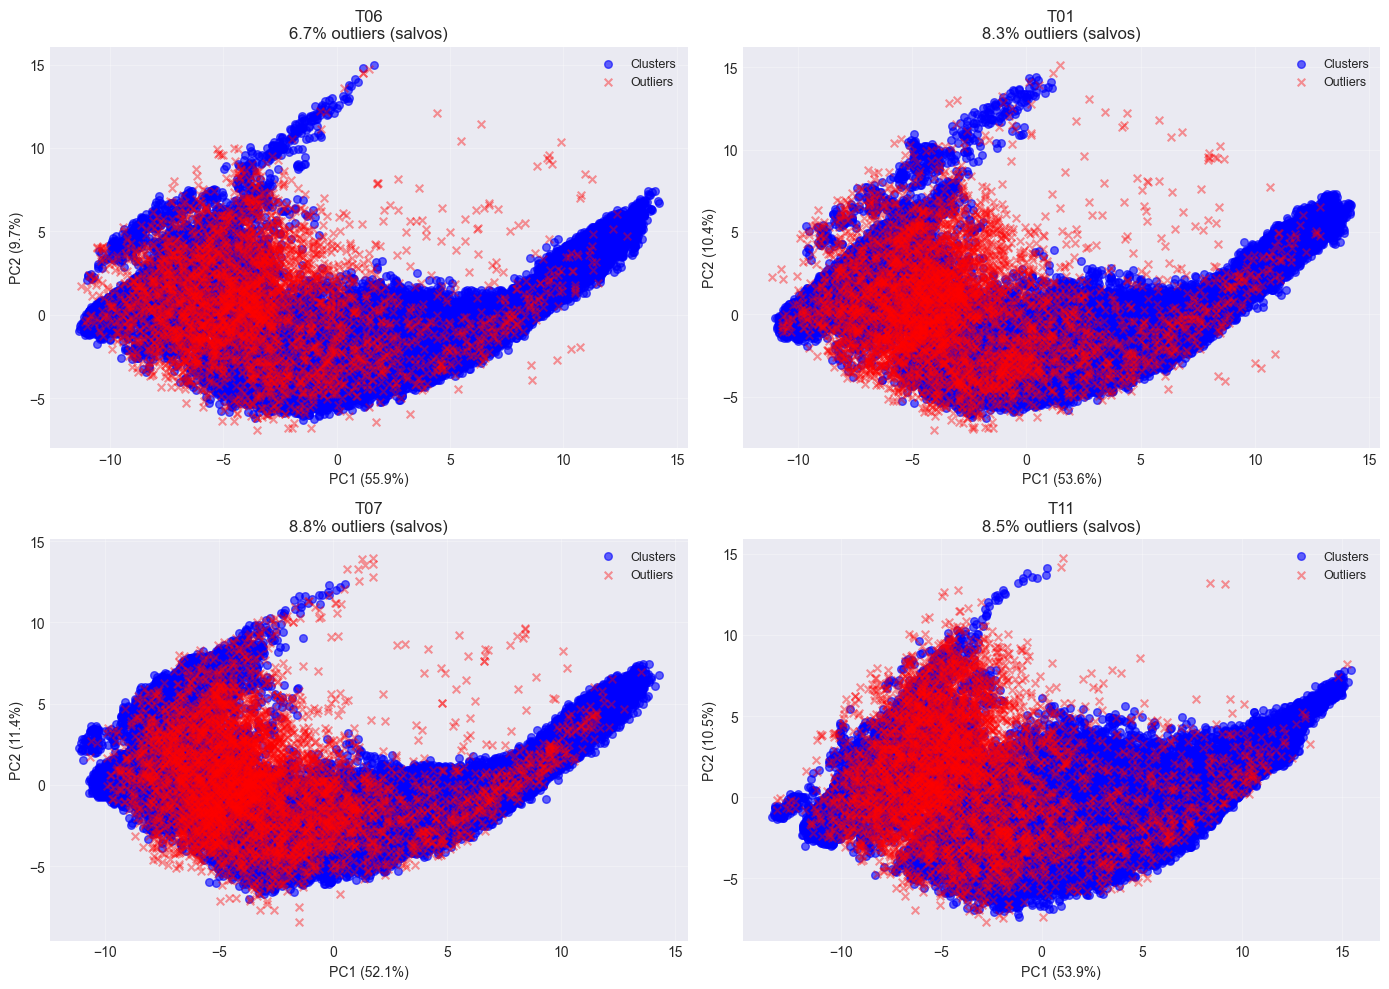

In [13]:
# Visualização DBSCAN: Usar coluna 'outlier_flag' salva (células 9/12)
print("=" * 70)
print("VISUALIZAÇÃO DBSCAN - OUTLIERS SALVOS")
print("=" * 70)

n_turbinas = len(turbinas_tratadas)
fig, axes = plt.subplots(2, (n_turbinas + 1) // 2, figsize=(14, 10))
axes = axes.flatten() if n_turbinas > 1 else [axes]

for idx, (turbine_id, df_turb) in enumerate(turbinas_tratadas.items()):
    print(f"\nProcessando visualização: {turbine_id}")
    
    # Preparar dados (mesmos usados no processamento original)
    colunas_num = df_turb.select_dtypes(include=[np.number]).columns.tolist()
    if 'outlier_flag' in colunas_num:
        colunas_num.remove('outlier_flag')
    
    colunas_validas = [col for col in colunas_num if df_turb[col].notna().sum() > 0]
    dados = df_turb[colunas_validas].copy()
    
    # Aplicar APENAS PCA para visualização (dados já estão preenchidos)
    scaler = StandardScaler()
    dados_normalizados = scaler.fit_transform(dados)
    
    pca = PCA(n_components=0.95)
    dados_pca = pca.fit_transform(dados_normalizados)
    
    # Usar apenas 2 primeiras componentes para visualização
    pc1 = dados_pca[:, 0]
    pc2 = dados_pca[:, 1]
    
    # Usar outliers da coluna SALVA (não recalcular)
    mask_outliers = df_turb['outlier_flag'].values
    mask_clusters = ~mask_outliers
    
    # Plot clusters (todos em azul)
    if mask_clusters.sum() > 0:
        axes[idx].scatter(pc1[mask_clusters], pc2[mask_clusters],
                        c='blue', s=30, alpha=0.6, label='Clusters')
    
    # Plot outliers (vermelho com X)
    if mask_outliers.sum() > 0:
        axes[idx].scatter(pc1[mask_outliers], pc2[mask_outliers], 
                         c='red', marker='x', s=30, alpha=0.4, label='Outliers')
    
    # Estatísticas da coluna salva
    n_outliers = mask_outliers.sum()
    pct_outliers = (n_outliers / len(df_turb)) * 100
    
    axes[idx].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[idx].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[idx].set_title(f'{turbine_id}\n{pct_outliers:.1f}% outliers (salvos)')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='best', fontsize=9)
    
    print(f"  {dados_normalizados.shape[1]}D → {dados_pca.shape[1]}D (PCA para visualização)")
    print(f"  {pct_outliers:.1f}% outliers (da coluna 'outlier_flag')")

# Remover subplots vazios se houver
for idx in range(n_turbinas, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

 

In [14]:
# Verificação: Comparar outliers salvos vs recalculados
print("=" * 70)
print("VERIFICAÇÃO DE CONSISTÊNCIA - OUTLIERS")
print("=" * 70)

for turbine_id, df_turb in turbinas_tratadas.items():
    print(f"\n{turbine_id}:")
    
    # Outliers da coluna 'outlier_flag' (calculados na célula 9)
    outliers_salvos = df_turb['outlier_flag'].sum()
    pct_salvos = (outliers_salvos / len(df_turb)) * 100
    print(f"  Outliers SALVOS (célula 9): {outliers_salvos} ({pct_salvos:.2f}%)")
    
    # Preparar dados e recalcular DBSCAN (como nos gráficos)
    colunas_num = df_turb.select_dtypes(include=[np.number]).columns.tolist()
    if 'outlier_flag' in colunas_num:
        colunas_num.remove('outlier_flag')
    
    colunas_validas = [col for col in colunas_num if df_turb[col].notna().sum() > 0]
    dados = df_turb[colunas_validas].copy()
    
    # Mesmo processo das visualizações
    imputer = KNNImputer(n_neighbors=3)
    dados_preenchidos = pd.DataFrame(imputer.fit_transform(dados), columns=colunas_validas)
    scaler = StandardScaler()
    dados_normalizados = scaler.fit_transform(dados_preenchidos)
    
    pca = PCA(n_components=0.95)
    dados_pca = pca.fit_transform(dados_normalizados)
    
    dbscan = DBSCAN(eps=2.0, min_samples=5)
    labels = dbscan.fit_predict(dados_pca)
    
    outliers_recalc = (labels == -1).sum()
    pct_recalc = (outliers_recalc / len(labels)) * 100
    print(f"  Outliers RECALCULADOS (gráfico): {outliers_recalc} ({pct_recalc:.2f}%)")
    
    diferenca = abs(outliers_salvos - outliers_recalc)
    print(f"  Diferença: {diferenca} outliers")
    
    if diferenca > 0:
        print(f"  ⚠️ INCONSISTÊNCIA DETECTADA!")
    else:
        print(f"  ✅ Valores consistentes")

print("\n" + "=" * 70)
print("💡 Se houver diferença, os gráficos scatter mostram valores")
print("   RECALCULADOS (não salvos na coluna 'outlier_flag')")
print("=" * 70)

VERIFICAÇÃO DE CONSISTÊNCIA - OUTLIERS

T06:
  Outliers SALVOS (célula 9): 3501 (6.69%)
  Outliers RECALCULADOS (gráfico): 3501 (6.69%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T01:
  Outliers SALVOS (célula 9): 4350 (8.33%)
  Outliers RECALCULADOS (gráfico): 3501 (6.69%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T01:
  Outliers SALVOS (célula 9): 4350 (8.33%)
  Outliers RECALCULADOS (gráfico): 4350 (8.33%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T07:
  Outliers SALVOS (célula 9): 4605 (8.81%)
  Outliers RECALCULADOS (gráfico): 4350 (8.33%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T07:
  Outliers SALVOS (célula 9): 4605 (8.81%)
  Outliers RECALCULADOS (gráfico): 4605 (8.81%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T11:
  Outliers SALVOS (célula 9): 4446 (8.49%)
  Outliers RECALCULADOS (gráfico): 4605 (8.81%)
  Diferença: 0 outliers
  ✅ Valores consistentes

T11:
  Outliers SALVOS (célula 9): 4446 (8.49%)
  Outliers RECALCULADOS (gráfico): 4


VISUALIZAÇÃO DBSCAN - METMAST


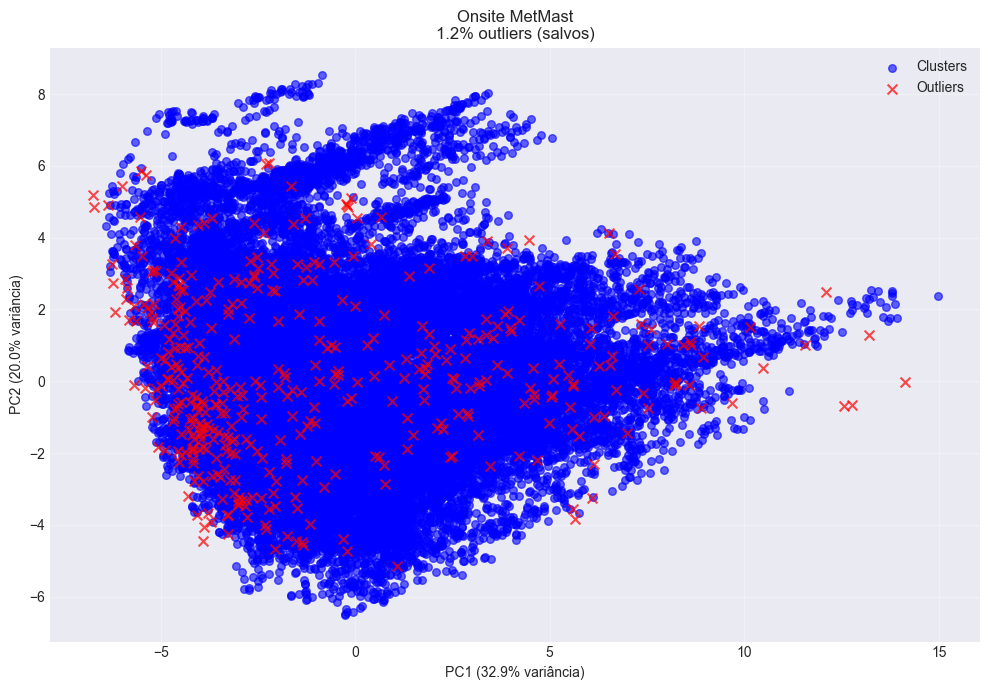


MetMast: 40D → 9D (PCA para visualização)
  1.2% outliers (da coluna 'outlier_flag')


In [15]:
# Visualização DBSCAN: MetMast (outliers salvos)
print("\n" + "=" * 70)
print("VISUALIZAÇÃO DBSCAN - METMAST")
print("=" * 70)

# Preparar dados MetMast
colunas_num_met = df_metmast_tratado.select_dtypes(include=[np.number]).columns.tolist()
if 'outlier_flag' in colunas_num_met:
    colunas_num_met.remove('outlier_flag')

colunas_validas_met = [col for col in colunas_num_met if df_metmast_tratado[col].notna().sum() > 0]
dados_met = df_metmast_tratado[colunas_validas_met].copy()

# Aplicar APENAS PCA para visualização (dados já preenchidos)
scaler_met = StandardScaler()
dados_normalizados_met = scaler_met.fit_transform(dados_met)

pca_met = PCA(n_components=0.95)
dados_pca_met = pca_met.fit_transform(dados_normalizados_met)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

pc1_met = dados_pca_met[:, 0]
pc2_met = dados_pca_met[:, 1]

# Usar outliers da coluna SALVA (não recalcular)
mask_outliers_met = df_metmast_tratado['outlier_flag'].values
mask_clusters_met = ~mask_outliers_met

# Plot clusters (todos em azul)
if mask_clusters_met.sum() > 0:
    ax.scatter(pc1_met[mask_clusters_met], pc2_met[mask_clusters_met],
              c='blue', s=30, alpha=0.6, label='Clusters')

# Plot outliers (vermelho com X)
if mask_outliers_met.sum() > 0:
    ax.scatter(pc1_met[mask_outliers_met], pc2_met[mask_outliers_met], 
              c='red', marker='x', s=50, alpha=0.7, label='Outliers')

# Estatísticas da coluna salva
n_outliers_met = mask_outliers_met.sum()
pct_outliers_met = (n_outliers_met / len(df_metmast_tratado)) * 100

ax.set_xlabel(f'PC1 ({pca_met.explained_variance_ratio_[0]*100:.1f}% variância)')
ax.set_ylabel(f'PC2 ({pca_met.explained_variance_ratio_[1]*100:.1f}% variância)')
ax.set_title(f'Onsite MetMast\n{pct_outliers_met:.1f}% outliers (salvos)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

print(f"\nMetMast: {dados_normalizados_met.shape[1]}D → {dados_pca_met.shape[1]}D (PCA para visualização)")
print(f"  {pct_outliers_met:.1f}% outliers (da coluna 'outlier_flag')")
print("=" * 70)

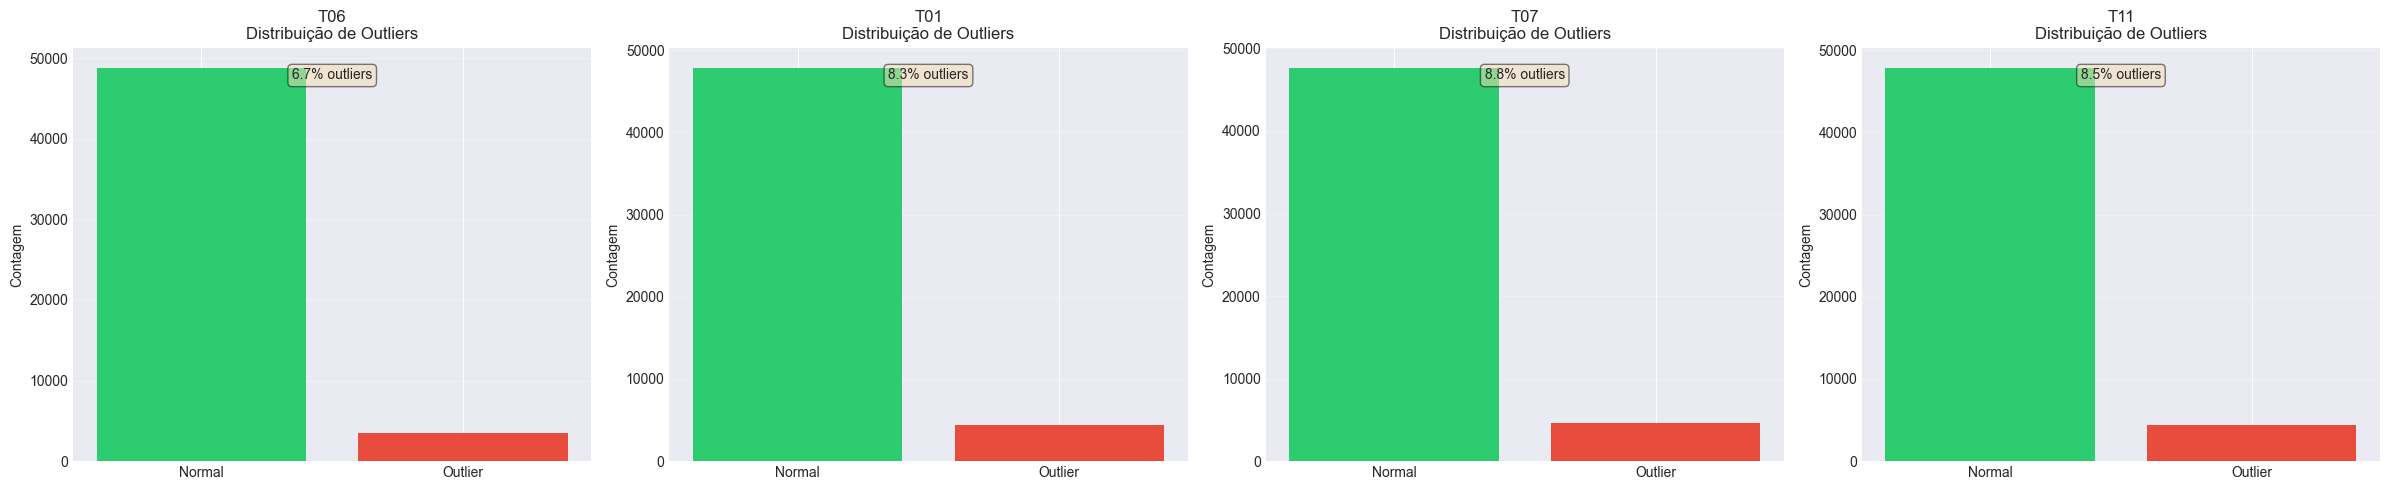

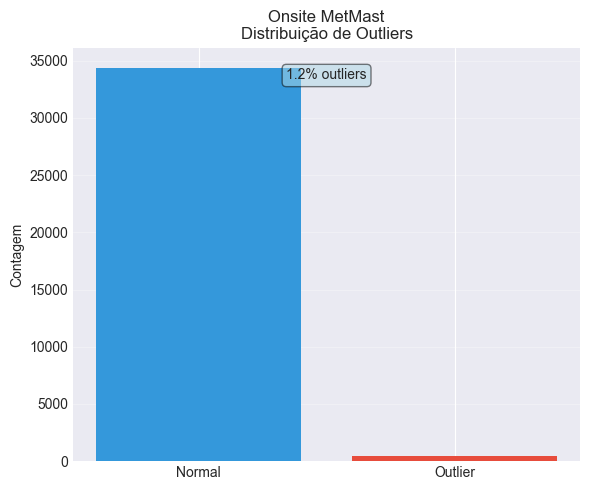

In [16]:
# Visualizar outliers POR TURBINA (comparativo)
n_turbinas = len(turbinas_tratadas)
n_metmast = 1  # MetMast é estação única

fig, axes = plt.subplots(1, max(n_turbinas, 2), figsize=(6*max(n_turbinas, 2), 5))
if n_turbinas == 1:
    axes = [axes]

# Plot para cada turbina
for idx, (turbine_id, df_turb) in enumerate(turbinas_tratadas.items()):
    outliers_turb = df_turb['outlier_flag'].value_counts()
    axes[idx].bar(['Normal', 'Outlier'], 
                  [outliers_turb.get(False, 0), outliers_turb.get(True, 0)], 
                  color=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{turbine_id}\nDistribuição de Outliers')
    axes[idx].set_ylabel('Contagem')
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Adicionar percentual
    total = len(df_turb)
    outlier_pct = (outliers_turb.get(True, 0) / total) * 100
    axes[idx].text(0.5, 0.95, f'{outlier_pct:.1f}% outliers', 
                   transform=axes[idx].transAxes, ha='center', va='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Plot para MetMast
fig2, ax2 = plt.subplots(1, 1, figsize=(6, 5))

outliers_met = df_metmast_tratado['outlier_flag'].value_counts()
ax2.bar(['Normal', 'Outlier'], 
        [outliers_met.get(False, 0), outliers_met.get(True, 0)], 
        color=['#3498db', '#e74c3c'])
ax2.set_title('Onsite MetMast\nDistribuição de Outliers')
ax2.set_ylabel('Contagem')
ax2.grid(axis='y', alpha=0.3)

total = len(df_metmast_tratado)
outlier_pct = (outliers_met.get(True, 0) / total) * 100
ax2.text(0.5, 0.95, f'{outlier_pct:.1f}% outliers', 
         transform=ax2.transAxes, ha='center', va='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Exportar Bases Tratadas

In [17]:
# Salvar bases tratadas (consolidadas E individuais)
import os

# Salvar consolidadas
df_turbine_tratado.to_csv('Wind_Turbine_SCADA_tratado_consolidado.csv', index=False)
df_metmast_tratado.to_csv('Onsite_MetMast_SCADA_tratado.csv', index=False)

# Salvar cada turbina separadamente (recomendado para análises individuais)
os.makedirs('turbinas_tratadas', exist_ok=True)

for turbine_id, df_turb in turbinas_tratadas.items():
    filename = f"turbinas_tratadas/{turbine_id}_tratado.csv"
    df_turb.to_csv(filename, index=False)
    print(f"✅ Salvo: {filename}")

print(f"\n✅ Salvo: Onsite_MetMast_SCADA_tratado.csv")

print("\n📦 Arquivos gerados:")
print("  Consolidados:")
print("    - Wind_Turbine_SCADA_tratado_consolidado.csv (todas turbinas)")
print("    - Onsite_MetMast_SCADA_tratado.csv (estação única)")
print("  Individuais por turbina:")
print(f"    - turbinas_tratadas/ ({len(turbinas_tratadas)} arquivos: {', '.join(turbinas_tratadas.keys())})")
print("\nCada arquivo contém:")
print("  • Outliers detectados POR turbina (coluna 'outlier_flag')")
print("  • Valores vazios preenchidos com KNN usando APENAS dados da mesma turbina")

✅ Salvo: turbinas_tratadas/T06_tratado.csv
✅ Salvo: turbinas_tratadas/T01_tratado.csv
✅ Salvo: turbinas_tratadas/T01_tratado.csv
✅ Salvo: turbinas_tratadas/T07_tratado.csv
✅ Salvo: turbinas_tratadas/T07_tratado.csv
✅ Salvo: turbinas_tratadas/T11_tratado.csv

✅ Salvo: Onsite_MetMast_SCADA_tratado.csv

📦 Arquivos gerados:
  Consolidados:
    - Wind_Turbine_SCADA_tratado_consolidado.csv (todas turbinas)
    - Onsite_MetMast_SCADA_tratado.csv (estação única)
  Individuais por turbina:
    - turbinas_tratadas/ (4 arquivos: T06, T01, T07, T11)

Cada arquivo contém:
  • Outliers detectados POR turbina (coluna 'outlier_flag')
  • Valores vazios preenchidos com KNN usando APENAS dados da mesma turbina
✅ Salvo: turbinas_tratadas/T11_tratado.csv

✅ Salvo: Onsite_MetMast_SCADA_tratado.csv

📦 Arquivos gerados:
  Consolidados:
    - Wind_Turbine_SCADA_tratado_consolidado.csv (todas turbinas)
    - Onsite_MetMast_SCADA_tratado.csv (estação única)
  Individuais por turbina:
    - turbinas_tratadas/ (4

## Resumo do Tratamento

### ✅ Processamento Isolado por Turbina/Estação

**Por que separar?**
- ✅ Evita contaminação entre turbinas defeituosas e saudáveis
- ✅ Outliers detectados dentro do contexto de cada turbina
- ✅ Valores vazios preenchidos usando apenas dados da mesma turbina
- ✅ Permite identificar qual(is) turbina(s) está(ão) com problemas

**Método aplicado em CADA turbina/estação:**
1. **Detecção de Outliers**: DBSCAN (eps=0.5, min_samples=5)
   - Aplicado separadamente em cada turbina
   - Outliers flagados mas valores preservados
   
2. **Preenchimento de Valores Vazios**: KNN (k=3)
   - Usa apenas vizinhos da MESMA turbina
   - Impacto mínimo nos dados originais

3. **Exportação**: Arquivos individuais + consolidado
   - Permite análise individual ou conjunta
   - Rastreabilidade por turbina

**Vantagens:**
- Se T01 está defeituosa, não afeta T06, T07 e T11
- KNN usa contexto local de cada turbina
- Escalabilidade para análises comparativas